# Type 2 Diabetes Risk Stratification - Data Cleaning and Focused EDA

This notebook prepares the PIMA Indians Diabetes dataset for downstream machine learning agents.

## Workflow
1. Load and inspect data
2. Replace invalid zero values with missing values
3. Impute missing values using median
4. Perform focused EDA for risk-relevant insights
5. Engineer clinically meaningful features
6. Save clean dataset for the ML pipeline

In [ ]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
%matplotlib inline

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("Libraries loaded.")

Libraries loaded.


## 1) Load Data

In [2]:
# Primary path required by project prompt
raw_path = Path("../data/raw/diabetes.csv")

# Fallback in case notebook is executed from repository root
if not raw_path.exists():
    raw_path = Path("data/raw/diabetes.csv")

df = pd.read_csv(raw_path)

print(f"Loaded dataset from: {raw_path}")
print(f"Shape: {df.shape}")

print("\nFirst 5 rows:")
display(df.head())

print("\nDataset info:")
df.info()

print("\nStatistical summary:")
display(df.describe())

Loaded dataset from: ../data/raw/diabetes.csv
Shape: (768, 9)

First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Statistical summary:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## 2) Handle Invalid Zero Values

In [3]:
invalid_zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

print("Missing values before replacing invalid zeros:")
missing_before = df[invalid_zero_cols].isna().sum()
display(missing_before)

zero_counts = (df[invalid_zero_cols] == 0).sum()
print("\nZero counts (to be treated as invalid):")
display(zero_counts)

# Replace invalid zeros with NaN
df[invalid_zero_cols] = df[invalid_zero_cols].replace(0, np.nan)

print("\nMissing values after replacing invalid zeros with NaN:")
missing_after = df[invalid_zero_cols].isna().sum()
display(missing_after)

Missing values before replacing invalid zeros:


Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


Zero counts (to be treated as invalid):


Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


Missing values after replacing invalid zeros with NaN:


Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

## 3) Handle Missing Values (Median Imputation)

Median is used because it is robust to outliers and skewed clinical measurements (for example insulin and glucose), making imputation more stable for healthcare modeling.

In [ ]:
print("Total missing values before imputation:")
print(df.isna().sum().sum())

numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

print("\nMissing values by column after imputation:")
display(df.isna().sum())

print("\nTotal missing values after imputation:")
print(df.isna().sum().sum())

Total missing values before imputation:
652

Missing values by column after imputation:


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


Total missing values after imputation:
0


## 4) Focused EDA

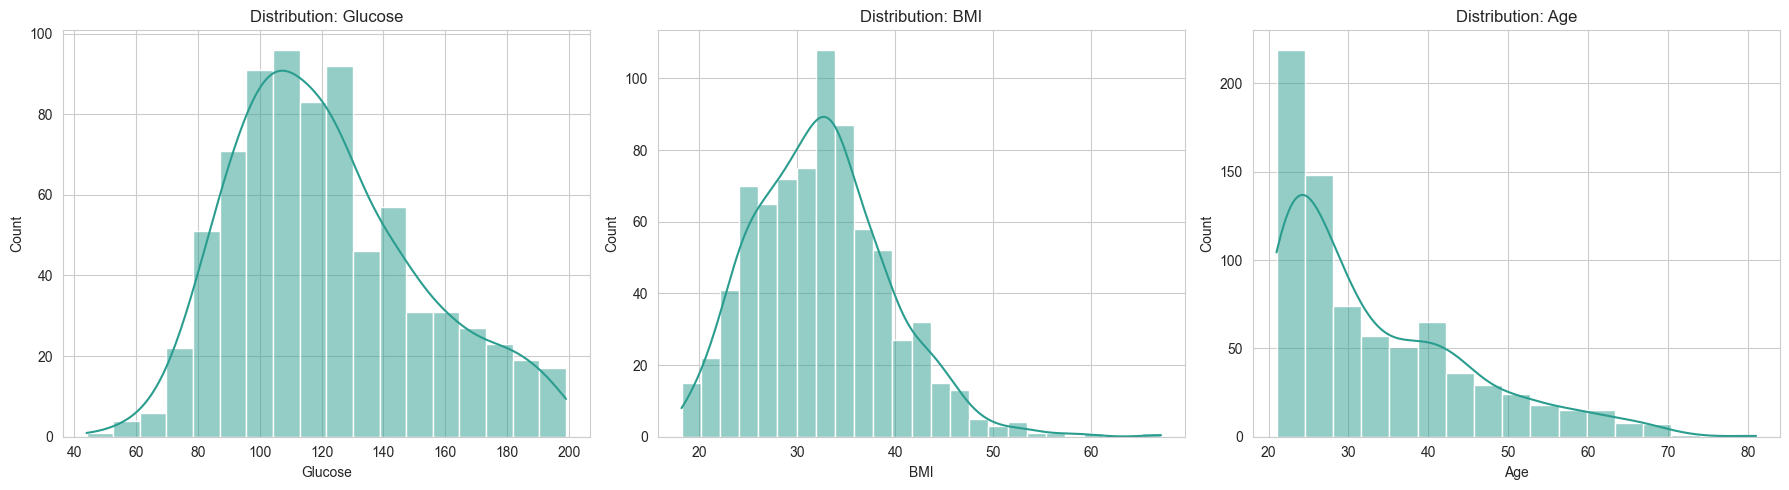

Distribution insights:
- Glucose is right-skewed with a longer upper tail, indicating a subset with elevated glycemic levels.
- BMI is mildly right-skewed, consistent with overweight/obesity prevalence in risk cohorts.
- Age is right-skewed with more participants in younger-middle age bands and fewer older individuals.


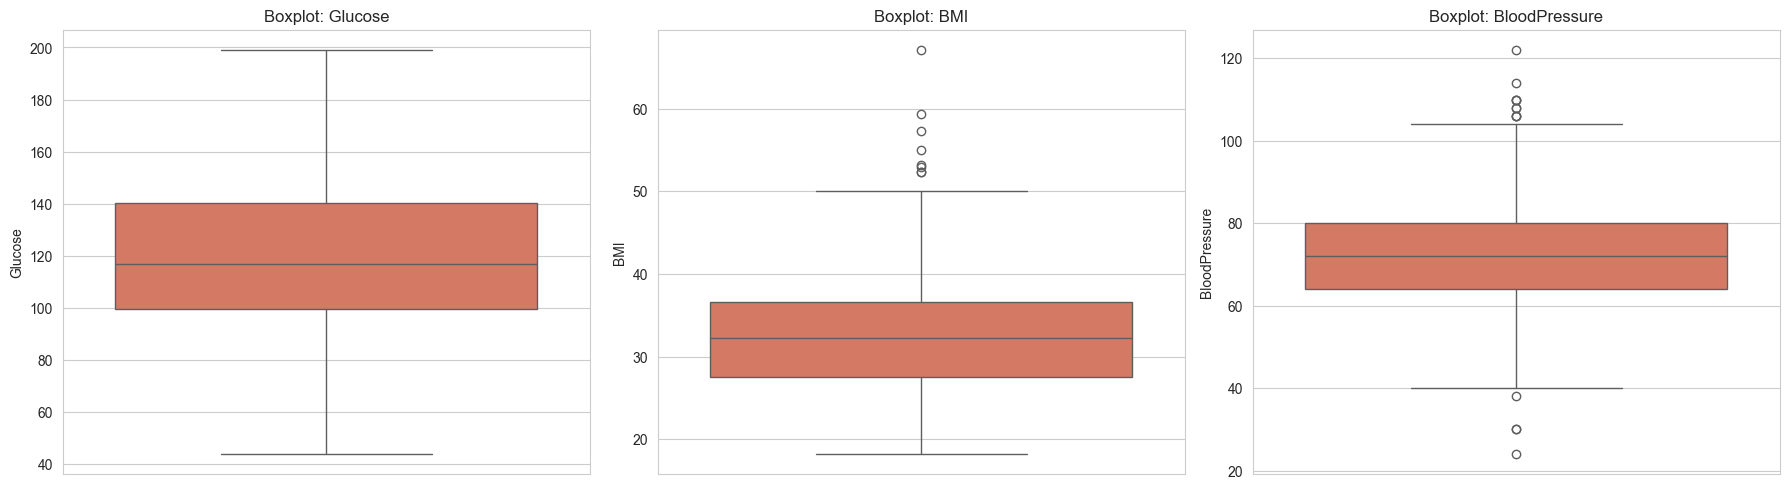


Outlier insights:
- Extreme values are visible, especially in Glucose and BMI.
- Outliers can strongly influence model decision boundaries and calibration.
- In healthcare, careful outlier handling is critical because some extremes are true high-risk patients, not noise.


In [ ]:
# 4.1 Feature distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ["Glucose", "BMI", "Age"]):
    sns.histplot(df[col], kde=True, ax=ax, color="#2a9d8f")
    ax.set_title(f"Distribution: {col}")
plt.tight_layout()
plt.show()

print("Distribution insights:")
print("- Glucose is right-skewed with a longer upper tail, indicating a subset with elevated glycemic levels.")
print("- BMI is mildly right-skewed, consistent with overweight/obesity prevalence in risk cohorts.")
print("- Age is right-skewed with more participants in younger-middle age bands and fewer older individuals.")

# 4.2 Outlier detection with boxplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ["Glucose", "BMI", "BloodPressure"]):
    sns.boxplot(y=df[col], ax=ax, color="#e76f51")
    ax.set_title(f"Boxplot: {col}")
plt.tight_layout()
plt.show()

print("\nOutlier insights:")
print("- Extreme values are visible, especially in Glucose and BMI.")
print("- Outliers can strongly influence model decision boundaries and calibration.")
print("- In healthcare, careful outlier handling is critical because some extremes are true high-risk patients, not noise.")

### 4.3 Correlation Analysis

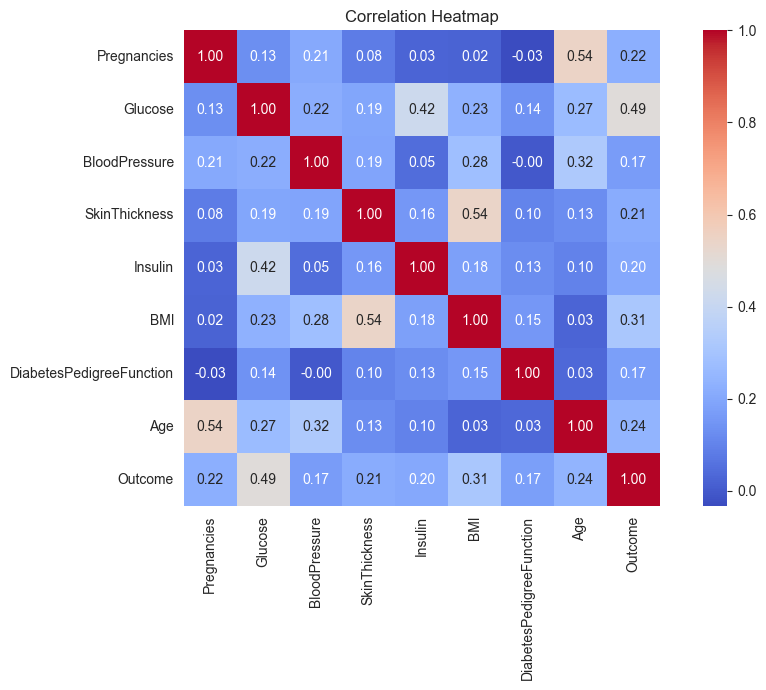

Correlation with Outcome:


Outcome                     1.000000
Glucose                     0.492782
BMI                         0.312038
Age                         0.238356
Pregnancies                 0.221898
SkinThickness               0.214873
Insulin                     0.203790
DiabetesPedigreeFunction    0.173844
BloodPressure               0.165723
Name: Outcome, dtype: float64

Key medically relevant relationships:
- Glucose usually shows the strongest positive association with diabetes outcome.
- BMI and Age often show moderate positive correlation with outcome.
- Pregnancies may have mild positive association, partly reflecting age and metabolic risk.


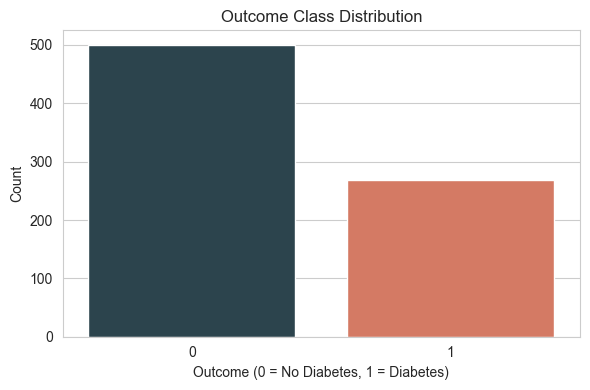


Outcome percentage distribution:
- No Diabetes: 65.10%
- Diabetes: 34.90%

Class imbalance check:
- Noticeable class imbalance exists; use stratified split and imbalance-aware metrics.


In [ ]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

outcome_corr = corr["Outcome"].sort_values(ascending=False)
print("Correlation with Outcome:")
display(outcome_corr)

print("Key medically relevant relationships:")
print("- Glucose usually shows the strongest positive association with diabetes outcome.")
print("- BMI and Age often show moderate positive correlation with outcome.")
print("- Pregnancies may have mild positive association, partly reflecting age and metabolic risk.")

# 4.4 Target variable analysis
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Outcome", palette=["#264653", "#e76f51"])
plt.title("Outcome Class Distribution")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

outcome_pct = (df["Outcome"].value_counts(normalize=True) * 100).sort_index()
print("\nOutcome percentage distribution:")
for cls, pct in outcome_pct.items():
    label = "No Diabetes" if cls == 0 else "Diabetes"
    print(f"- {label}: {pct:.2f}%")

print("\nClass imbalance check:")
if outcome_pct.max() - outcome_pct.min() > 20:
    print("- Noticeable class imbalance exists; use stratified split and imbalance-aware metrics.")
else:
    print("- Mild to moderate imbalance; still use stratified splitting for robust evaluation.")

## 5) Feature Engineering

In [ ]:
# BMI categories
bmi_bins = [-np.inf, 25, 30, np.inf]
bmi_labels = ["Normal", "Overweight", "Obese"]
df["BMI_Category"] = pd.cut(df["BMI"], bins=bmi_bins, labels=bmi_labels, right=False)

# Glucose categories
glucose_bins = [-np.inf, 140, 200, np.inf]
glucose_labels = ["Normal", "Prediabetic", "Diabetic"]
df["Glucose_Category"] = pd.cut(df["Glucose"], bins=glucose_bins, labels=glucose_labels, right=False)

print("Engineered feature preview:")
display(df[["BMI", "BMI_Category", "Glucose", "Glucose_Category"]].head())

print("\nBMI category distribution:")
display(df["BMI_Category"].value_counts())

print("Glucose category distribution:")
display(df["Glucose_Category"].value_counts())

# 6) Save cleaned data
processed_path = Path("../data/processed/cleaned_diabetes.csv")
if not processed_path.parent.exists():
    processed_path = Path("data/processed/cleaned_diabetes.csv")
    processed_path.parent.mkdir(parents=True, exist_ok=True)

# Final data quality check before saving
assert df.isna().sum().sum() == 0, "Dataset still contains missing values."

df.to_csv(processed_path, index=False)
print(f"\nCleaned dataset saved to: {processed_path}")
print(f"Final shape: {df.shape}")
print("Dataset is ML-ready for preprocessing and risk stratification agents.")

Engineered feature preview:


,BMI,BMI_Category,Glucose,Glucose_Category
0,33.6,Obese,148.0,Prediabetic
1,26.6,Overweight,85.0,Normal
2,23.3,Normal,183.0,Prediabetic
3,28.1,Overweight,89.0,Normal
4,43.1,Obese,137.0,Normal



BMI category distribution:


BMI_Category
Obese         483
Overweight    179
Normal        106
Name: count, dtype: int64

Glucose category distribution:


Glucose_Category
Normal         571
Prediabetic    197
Diabetic         0
Name: count, dtype: int64


Cleaned dataset saved to: ../data/processed/cleaned_diabetes.csv
Final shape: (768, 11)
Dataset is ML-ready for preprocessing and risk stratification agents.
